# Notebook 1 — Structure Preparation and Bonding

## What is this tutorial about?

This notebook is the first in a series of six that walk you through computing
**Bond-Network Entropy (BNE)** — a single number that measures how structurally disordered
a material is at the level of its bond network.

We use **silica glass (SiO₂)** as our running example. Silica glass has very peaked (ordered) coordination
number distribution (almost every Si is bonded to 4 oxygens; almost every O to 2 silicons), yet it is
spatially disordered: the local environments have rings with irregular sizes and shapes. BNE is designed
to capture exactly that kind of topological disorder.

---

## The BNE pipeline — how the six notebooks fit together

| Step | Notebook | What we compute |
|------|----------|-----------------|
| 1 | **Notebook 1** (this one) | Interatomic distances; choice of bond cutoff |
| 2 | **Notebook 2** | Adjacency matrix; coordination numbers |
| 3 | **Notebook 3** | H₁ barcode for each atom's local atomic environment (LAE) |
| 4 | **Notebook 4** | BNE = Shannon entropy of the barcode distribution across all atoms |
| 5 | `5_BNE_workflow.py` | Repeat for many LAE sizes 1–80 (run from the terminal), precomputed values available |
| 6 | **Notebook 6** | BNE growth rate and saturation as a function of LAE size |

---

## The structure file

We load a **POSCAR file** — the standard VASP format for atomic structures. It contains
lattice vectors (the size and shape of the periodic simulation box) and atomic positions
in fractional coordinates.

Our silica glass has **5184 atoms** (3456 O + 1728 Si) in a cubic box of side ~42.8 Å.
The structure is taken from the following reference
(source: [PNAS 2025](https://www.pnas.org/doi/abs/10.1073/pnas.2422763122)).

## Library + visualization setup

In [1]:
import os, sys

import numpy as np
import pandas as pd
import scipy
from scipy.constants import physical_constants

import ase
from ase.io import read, write

matplotlib_style = 'fivethirtyeight'
import matplotlib.pyplot as plt
plt.style.use(matplotlib_style)
import seaborn as sns
sns.set_context('notebook')


# see https://github.com/CamDavidsonPilon/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers
# for inspiration and other tricks with visualization
class _Colors(object):
    """Helper class with different colors for plotting"""
    red = '#F15854'
    blue = '#5DA5DA'
    orange = '#FAA43A'
    green = '#60BD68'
    pink = '#F17CB0'
    brown = '#B2912F'
    purple = '#B276B2'
    yellow = '#DECF3F'
    gray = '#4D4D4D'
    cyan = '#00FFFF'
    rebecca_purple = '#663399'
    chartreuse = '#7FFF00'
    dark_red = '#8B0000'

    def __getitem__(self, i):
        color_list = [
            self.red,
            self.orange,
            self.green,
            self.blue,
            self.pink,
            self.brown,
            self.purple,
            self.yellow,
            self.gray,
            self.cyan,
            self.rebecca_purple,
            self.chartreuse,
            self.dark_red
        ]
        return color_list[i % len(color_list)]


Colors = _Colors()

from typing import Tuple, List
from tqdm import tqdm


## Step 1 — Finding interatomic distances (Minimum Image Convention)

To decide which atoms are bonded we first need all pairwise distances.

**Why is this tricky in a periodic structure?**
Atomistic simulations use **periodic boundary conditions (PBC)**: the simulation box is
tiled infinitely in all three directions. An atom near one face of the box can be bonded
to an atom that appears on the *opposite* face — their true nearest-image distance is short
even though their raw coordinate difference is large.

The **Minimum Image Convention (MIC)** gives the correct distance and is implemented in ASE:
ASE's `atoms.get_distances(..., mic=True)`

The function below computes, for every atom, the distances to its `n_smallest` nearest
neighbours, sorted from closest to furthest. We store them as two arrays of shape
`(N_atoms, n_smallest)`:
- `distances[i, k]` — distance from atom $i$ to its $k$-th nearest neighbour
- `idx_distances[i, k]` — global index of that neighbour

In [2]:
# read structure downloaded from https://www.pnas.org/doi/abs/10.1073/pnas.2422763122
filename = "./data/structural/silica_glass_5184_atoms/POSCAR"

atoms = read(filename)
atoms

Atoms(symbols='O3456Si1728', pbc=True, cell=[42.7702331357, 42.7702331357, 42.7702331357])

In [3]:
atomic_numbers = atoms.get_atomic_numbers()
atomic_numbers  # 8 is oxygen, 14 is silicon

array([ 8,  8,  8, ..., 14, 14, 14], shape=(5184,))

From atomic numbers, we can see that first 2/3 of indices are oxygen, last 1/3 is silicon, this will be used later

In [4]:
# handy function to obtain distances to nearest atoms (distances) and their indices (idx_distances)

def obtain_distances_ase(
    atoms: ase.atoms.Atoms,
    n_smallest: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute the n_smallest nearest-neighbour distances for every atom using
    the ASE Minimum Image Convention (preferred method).

    ASE's ``get_distances`` method handles the MIC correctly for all cell
    shapes (orthorhombic, monoclinic, triclinic), making it more accurate
    than the manual implementation for non-cubic cells.

    Parameters
    ----------
    atoms : ase.atoms.Atoms
        ASE Atoms object containing positions and cell (lattice vectors).
        Load from file with ``ase.io.read(filename)``.
    n_smallest : int
        Number of nearest neighbours (including central atom) to keep per atom.

    Returns
    -------
    distances : np.ndarray, shape (N, n_smallest)
        Sorted nearest-neighbour distances (in Ångström).
    idx_distances : np.ndarray, shape (N, n_smallest)
        Global atom indices corresponding to those distances.
    """

    distances = []
    idx_distances = []

    nat = len(atoms)
    atom_indices = np.arange(0, nat, 1)

    for k in tqdm(range(len(atoms)), desc="Distances"):

        # ASE computes MIC-corrected distances from atom k to all others
        distance = atoms.get_distances(k, atom_indices, mic=True)

        # keep only the n_smallest nearest neighbours using argpartition
        if n_smallest < nat:
            idx_distance = np.argpartition(distance, n_smallest)[:n_smallest]
        else:
            idx_distance = np.arange(0, nat, 1)

        # sort by distance within the selected neighbours
        idx_distance = idx_distance[np.argsort(distance[idx_distance])]

        idx_distances.append(idx_distance)
        distances.append(distance[idx_distance])

    distances = np.array(distances)
    idx_distances = np.array(idx_distances)
    return distances, idx_distances


> **Timing note:** The cell below loops over all 5184 atoms and calls ASE's MIC distance
> routine for each one. On a typical laptop this takes **15-30 seconds**. The `%%time` magic
> will print the exact wall-clock time when it finishes. You only need to run this once per
> session — all later notebooks reuse the same computation.

In [5]:
%%time
distances, idx_distances = obtain_distances_ase(atoms, 300)

Distances: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5184/5184 [00:13<00:00, 373.39it/s]

CPU times: user 11.6 s, sys: 4.52 s, total: 16.1 s
Wall time: 13.9 s


In [6]:
distances[0, :30]

array([0.        , 1.59823125, 1.59995058, 2.53651019, 2.55824096,
       2.57382612, 2.61360709, 2.64484089, 2.72432556, 3.12889256,
       3.33988123, 3.52683473, 3.66502544, 3.67642757, 3.7418959 ,
       3.81488167, 3.99920102, 4.03340691, 4.1437194 , 4.18815551,
       4.26071218, 4.35772077, 4.39811906, 4.4680171 , 4.53320779,
       4.60976551, 4.78718661, 4.83595509, 4.88701397, 4.98273803])

## Step 2 — Reading the distance distribution

We plot the 30 nearest-neighbour distances for every atom as a scatter plot. Each point is
one (atom, neighbour) pair. The y-axis is the normalised atom index (0 = first O, 1 = last Si),
so the black horizontal line at 2/3 separates the oxygen atoms (below) from the silicon atoms
(above).

We use a scatter plot rather than a histogram to show every data point without binning artefacts.
Look for **distinct vertical bands** — these are coordination shells.

The purple vertical line marks our candidate bond cutoff at **2.1 Å**.

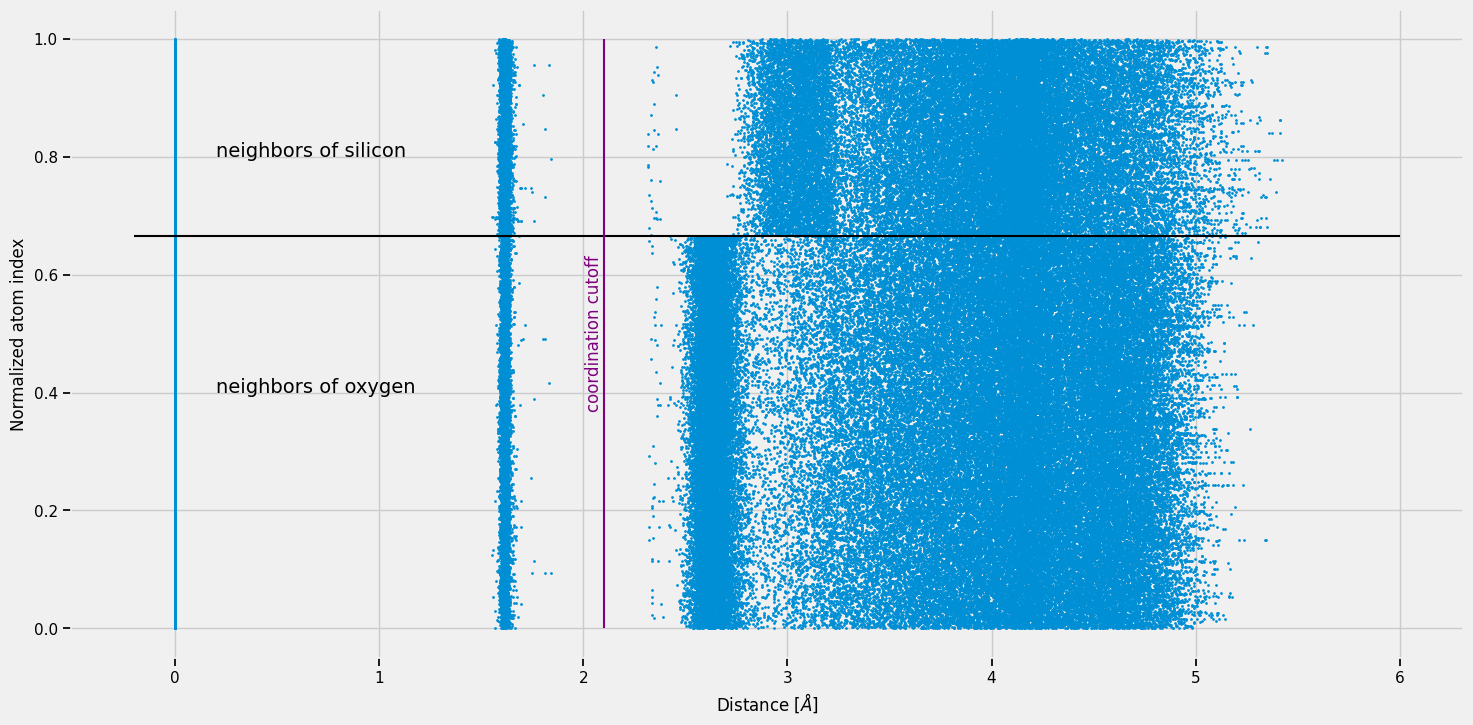

In [7]:
plt.figure(figsize=(16, 8))

n_closest_neigh = 30

nat = len(atoms)
spectrum = np.linspace(0, 1, nat)
normalized_atomic_indices = np.repeat(spectrum, n_closest_neigh).reshape(nat, n_closest_neigh)

plt.scatter(distances[:, :n_closest_neigh], normalized_atomic_indices, s=1)



plt.hlines(2/3, -0.2, 6, color="black")

plt.text(0.2, 0.8, "neighbors of silicon", fontsize=14)
plt.text(0.2, 0.4, "neighbors of oxygen", fontsize=14)



plt.vlines(2.1, 0, 1, color='purple')

plt.text(2.05, 0.5, 'coordination cutoff',
        horizontalalignment='center',
        verticalalignment='center',
        rotation='vertical', color='purple')



plt.ylabel("Normalized atom index")
plt.xlabel(r"Distance [$\AA$]")

plt.show()

Let's analyze the atom type of the neighbours

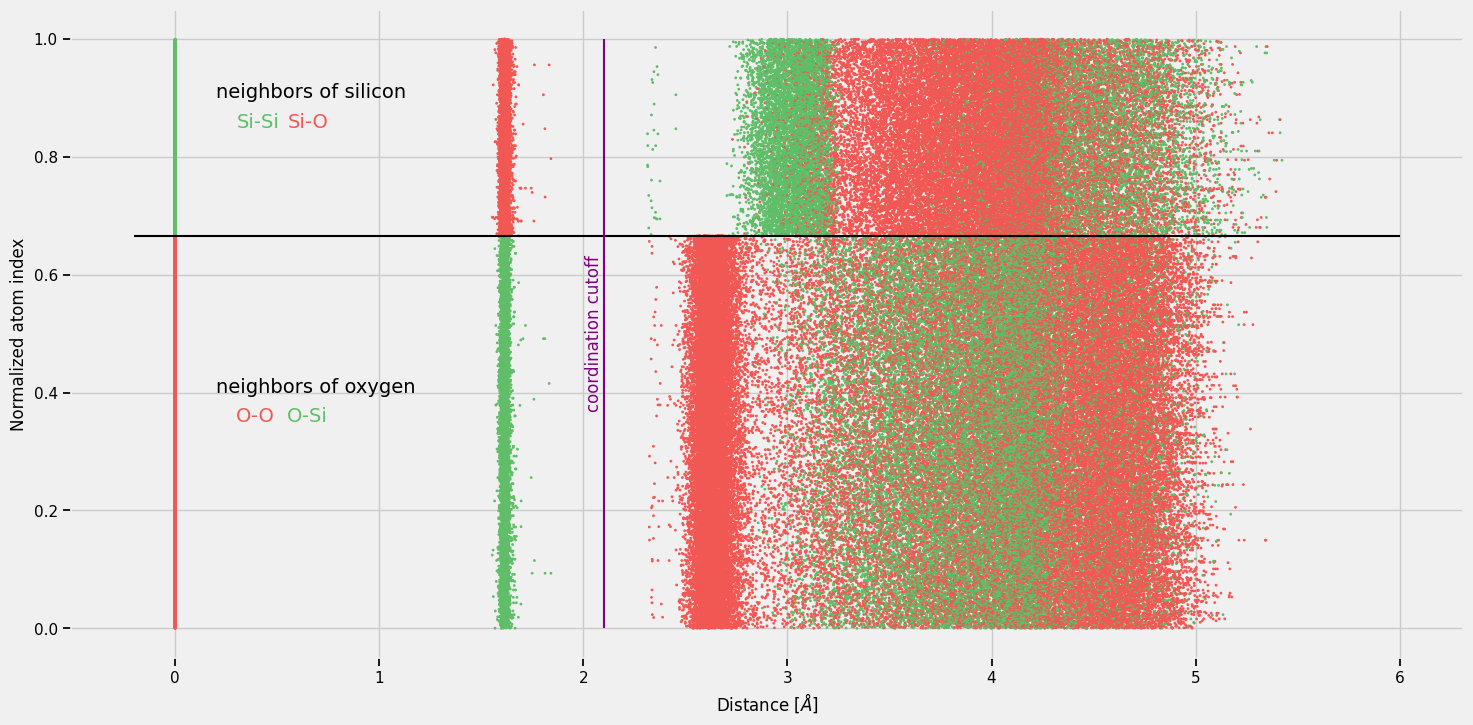

In [8]:
plt.figure(figsize=(16, 8))

n_closest_neigh = 30

nat = len(atoms)
spectrum = np.linspace(0, 1, nat)
normalized_atomic_indices = np.repeat(spectrum, n_closest_neigh).reshape(nat, n_closest_neigh)

vis_colors = {8:Colors[0], 14:Colors[2]} # oxygen is red, silicon is green

def apply_color(idx):
    return vis_colors[idx]

color_array = np.vectorize(apply_color)(atomic_numbers[idx_distances[:, :n_closest_neigh]])


plt.scatter(distances[:, :n_closest_neigh].flatten(), normalized_atomic_indices.flatten(), s=1, c=color_array.flatten())




plt.hlines(2/3, -0.2, 6, color="black")

plt.text(0.2, 0.9, "neighbors of silicon", fontsize=14)
plt.text(0.2, 0.4, "neighbors of oxygen", fontsize=14)

plt.text(0.3, 0.85, "Si-Si", fontsize=14, color=Colors[2])
plt.text(0.55, 0.85, "Si-O", fontsize=14, color=Colors[0])

plt.text(0.3, 0.35, "O-O", fontsize=14, color=Colors[0])
plt.text(0.55, 0.35, "O-Si", fontsize=14, color=Colors[2])




plt.vlines(2.1, 0, 1, color='purple')

plt.text(2.05, 0.5, 'coordination cutoff',
        horizontalalignment='center',
        verticalalignment='center',
        rotation='vertical', color='purple')


plt.ylabel("Normalized atom index")
plt.xlabel(r"Distance [$\AA$]")

plt.show()

The cutoff of **2.1 Å** (purple line) captures all Si–O nearest-neighbour bonds while
excluding all Si–Si and O–O pairs — exactly what we want for the silica bond network. For adjacency matrix we will also remove self-distances (band at distance = 0.0 Å).

## How to choose the cutoff for a different material

The cutoff `r_c = 2.1 Å` is specific to silica. For a **new material**, follow these steps:

1. **Plot the distance distribution** (as above). Look for a clear gap or valley between
   the first peak (nearest-neighbour bonds) and the second peak (next-nearest neighbours).
2. **Place `r_c` inside that gap.** For silica, Si–O bonds are ~1.6 Å and the first
   gap extends from ~1.9 Å to ~2.2 Å — any cutoff in that range works.
3. Some materials don't have a single cutoff, and **atom-dependent cutoffs** might have to be used. The distance is also not always a good descriptor of whether atoms are bonded, electronic charge density might be a better descriptor in such cases, but this goes beyond the scope of this tutorial.

**Considerations that change between materials:**
- **Bond lengths depend on the element pair.** C–C bonds in amorphous carbon are ~1.3–1.6 Å;
  Si–O bonds in silica glass are ~1.6 Å
- **Exclude second-shell atoms.** Setting the cutoff too large inflates coordination numbers
  and distorts the ring topology that BNE measures.
- **For multi-component systems,** the distance plot coloured by atom type (above) is especially
  helpful for identifying which peaks correspond to which bond pairs.